<a href="https://colab.research.google.com/github/DeeptiChedulla/Chocolate-Shipment-sale-data-analysis-using-powerBI/blob/main/Customer_churn_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

**Load data file**

In [ ]:
df=pd.read_csv("/content/CustomerChurn.csv")

**Top 5 records of data**

In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


**shape rows,columns**

In [ ]:
df.shape

(7043, 21)

In [ ]:
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


Senior citizen is actually a
categorical hence the 25%-50%-75% distribution is not propoer (categorical)

From tenure customers upto 75% having less than 55 months tenure

From monthlycharges average charges are 64.7 usd

In [ ]:
df['Churn'].value_counts()/len(df)*100

,count
Churn,
No,73.463013
Yes,26.536987


Text(0.5, 1.0, 'Churn counts')

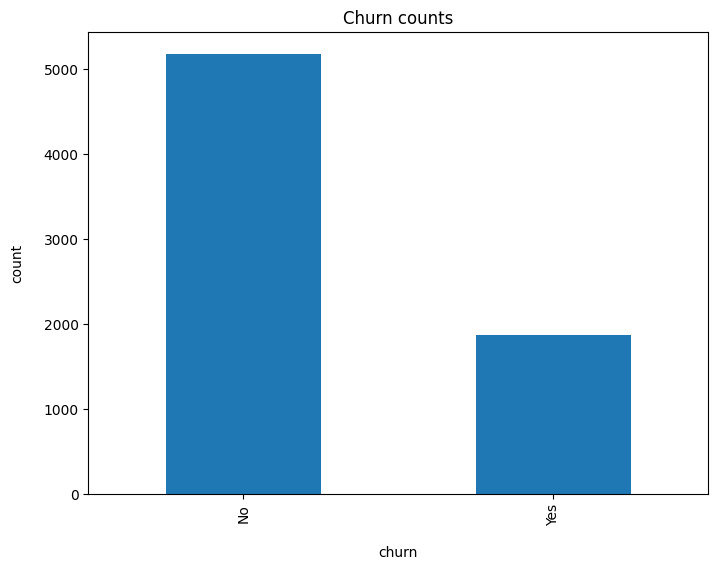

In [ ]:
df['Churn'].value_counts().plot(kind='bar',figsize=(8,6))
plt.ylabel("count",labelpad=14)
plt.xlabel("churn",labelpad=14)
plt.title("Churn counts")

In [ ]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


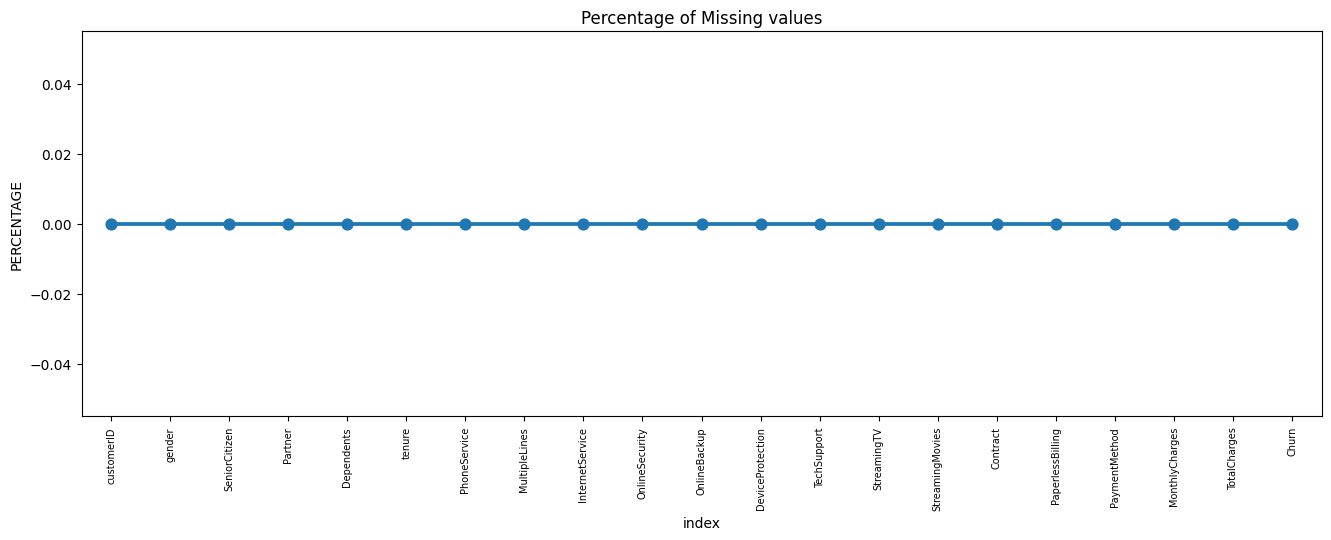

In [ ]:
missing=pd.DataFrame((df.isnull().sum())*100/df.shape[0]).reset_index()
plt.figure(figsize=(16,5))
ax=sns.pointplot(x='index',y=0,data=missing)
plt.xticks(rotation=90,fontsize=7)
plt.title("Percentage of Missing values")
plt.ylabel("PERCENTAGE")
plt.show()

**No missing values**
if there and less missing values use regression for predicting missing values or filling with mean, median, mode, ffill, bfill

if high drop row or column

and also check whether there is any impacted column by droping

**Data Cleaning**

In [ ]:
new_df=df.copy()

**Total charges should be numeric**

In [ ]:
new_df.TotalCharges=pd.to_numeric(new_df.TotalCharges,errors='coerce')
new_df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


**As we can see there are 11 missing values in Totalcharges column**

In [ ]:
new_df.loc[new_df['TotalCharges'].isnull()==True]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


**Handling missing values**

In [ ]:
new_df.dropna(how='any',inplace=True)

In [ ]:
new_df.loc[new_df['TotalCharges'].isnull()==True]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


Divide customers into bins based on tenure e.g for tenure<12 months: assign a tenure group if 1-12 for so on

In [ ]:
print(new_df['tenure'].max())

72


In [ ]:
labels=["{0}-{1}".format(i,i+11) for i in range(1,72,12)]
print(labels)

['1-12', '13-24', '25-36', '37-48', '49-60', '61-72']


In [ ]:
new_df['tenure_group']=pd.cut(new_df.tenure,range(1,80,12),right=False, labels=labels)

In [ ]:
new_df['tenure_group'].value_counts()

,count
tenure_group,
1-12,2175
61-72,1407
13-24,1024
25-36,832
49-60,832
37-48,762


**Remove columns not required for processing**

In [ ]:
new_df.drop(columns=['customerID','tenure'],axis=1,inplace=True)

In [ ]:
new_df.head()

,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group
0,Female,0,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,1-12
1,Male,0,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No,25-36
2,Male,0,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1-12
3,Male,0,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,37-48
4,Female,0,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1-12


**Data Exploration**

plot distribution of individual predictors by churn

**Univariate Analysis**

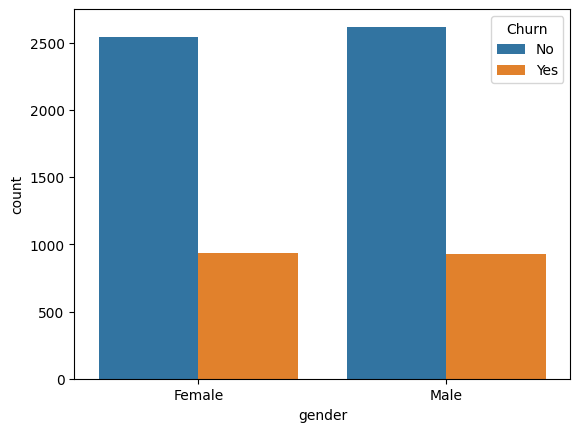

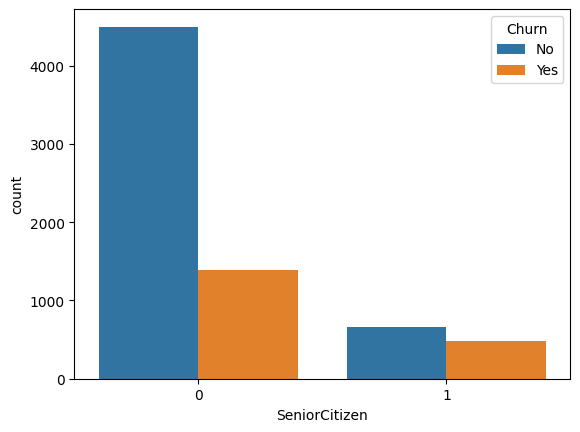

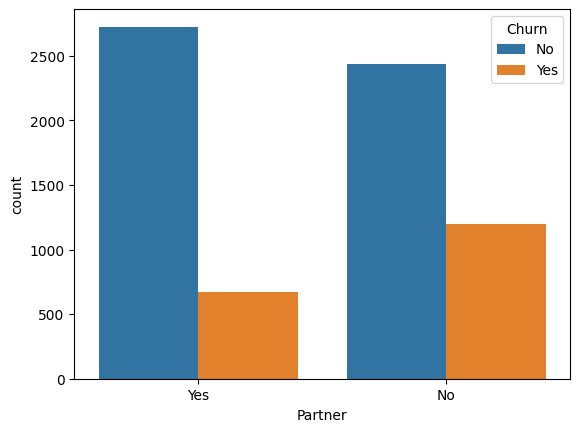

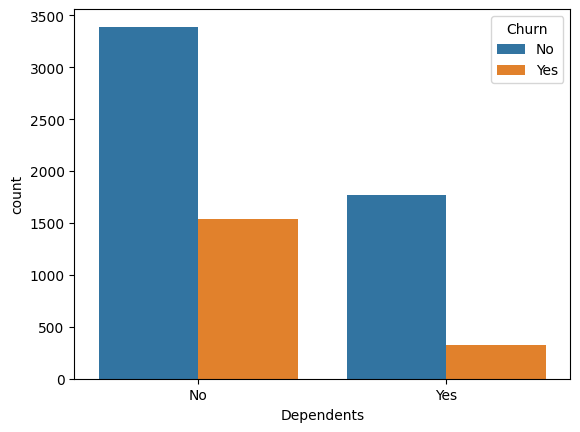

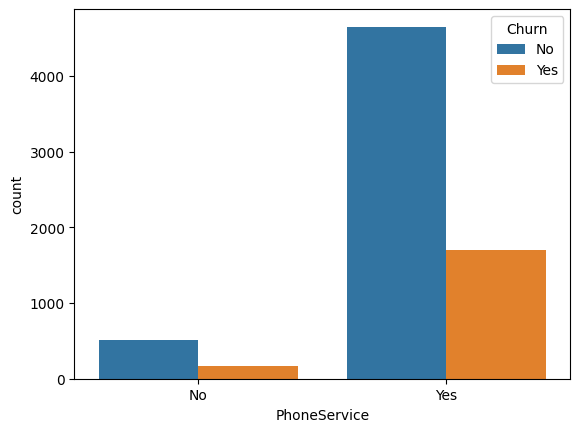

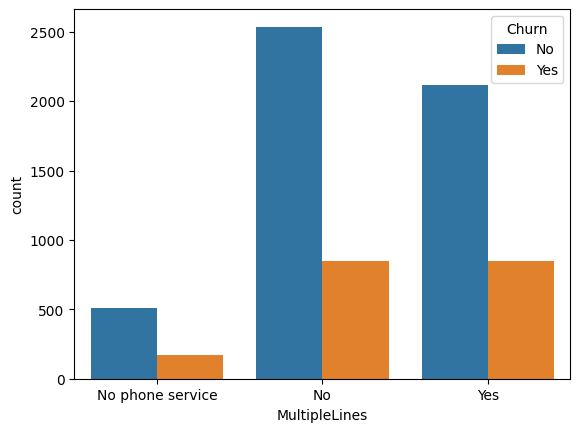

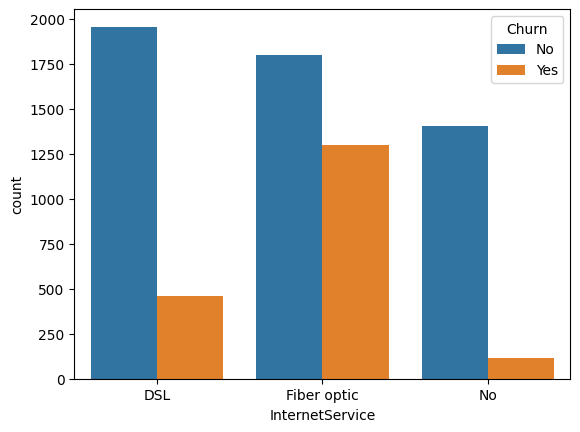

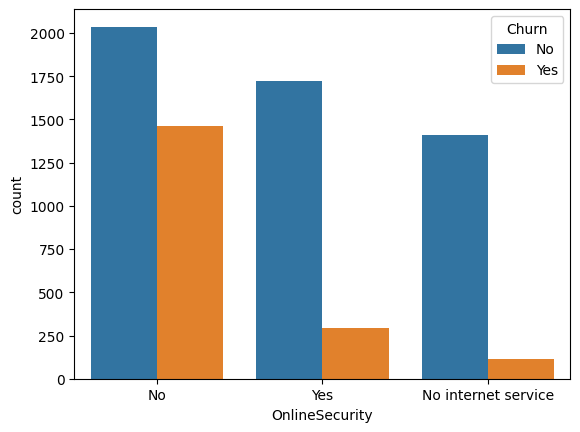

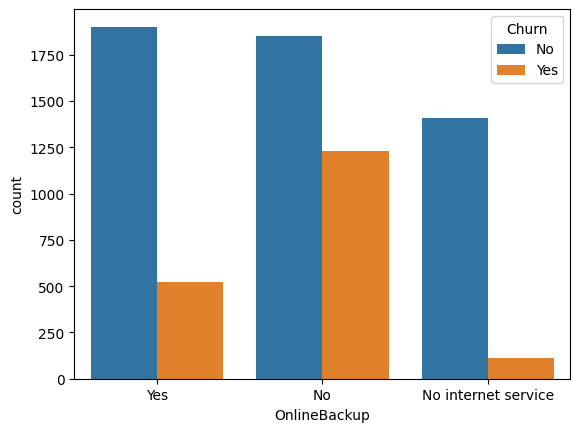

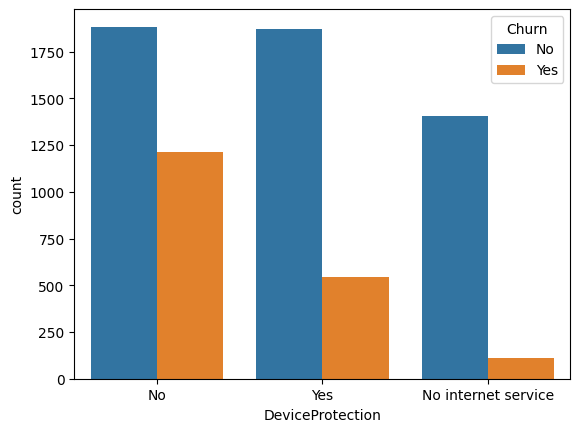

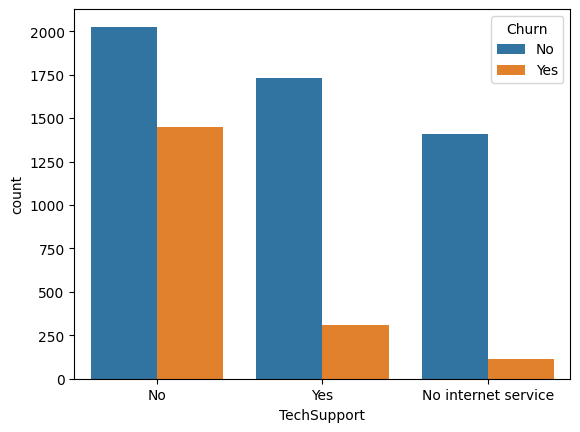

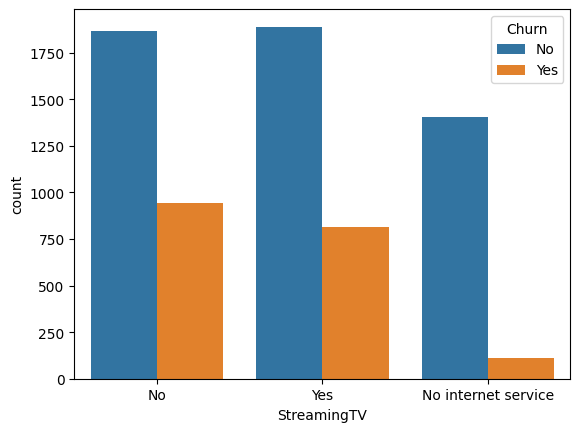

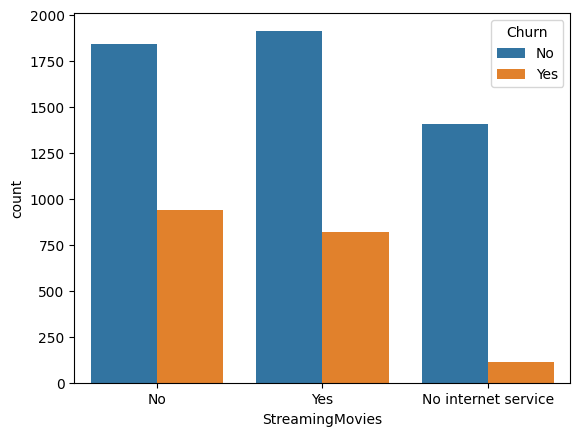

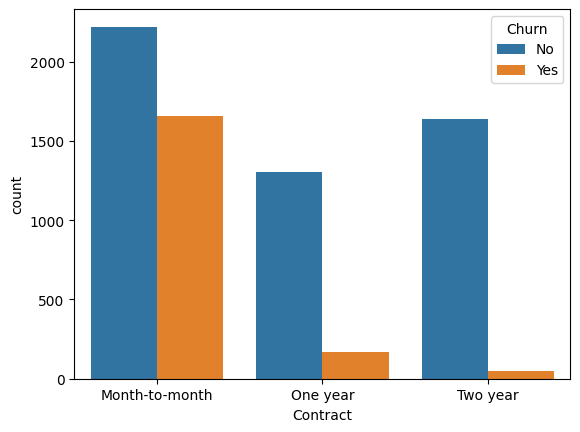

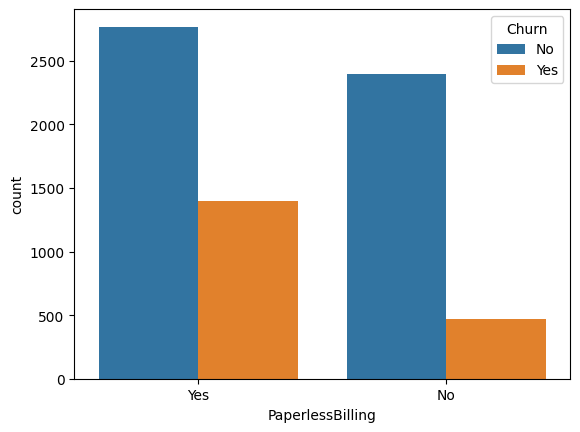

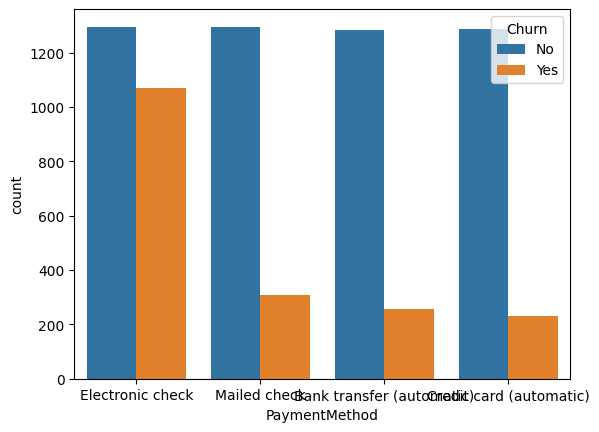

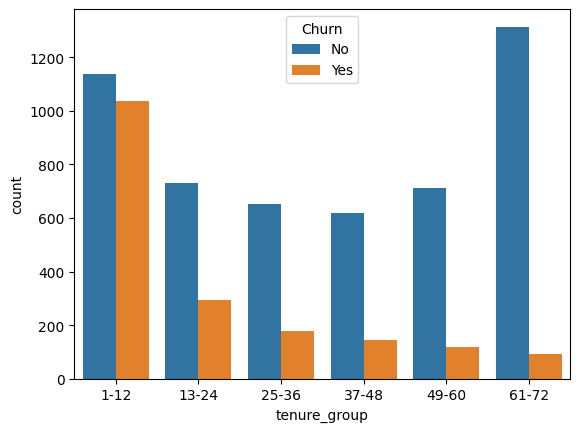

In [ ]:
for i, predictor in enumerate(new_df.drop(columns=['Churn','TotalCharges','MonthlyCharges'])):
  plt.figure(i)
  sns.countplot(data=new_df,x=predictor,hue='Churn')

**Numerical Analysis**

In [ ]:
new_df.gender.value_counts()

,count
gender,
Male,3549
Female,3483


In [ ]:
new_df1_target0=new_df[new_df['Churn']=='No']
new_df1_target1=new_df[new_df['Churn']=='Yes']

In [ ]:
new_df1_target1.gender.value_counts()

,count
gender,
Female,939
Male,930


In [ ]:
new_df.gender.value_counts()

,count
gender,
Male,3549
Female,3483


In [ ]:
pd.crosstab(new_df.PaymentMethod,new_df.Churn)

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),1284,258
Credit card (automatic),1289,232
Electronic check,1294,1071
Mailed check,1296,308


Convert the target variable 'Churn' in a binary numerical variable

In [ ]:
new_df['Churn']=np.where(new_df.Churn=='Yes',1,0)

In [ ]:
new_df.head()

,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group
0,Female,0,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,1-12
1,Male,0,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0,25-36
2,Male,0,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,1-12
3,Male,0,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,37-48
4,Female,0,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,1-12


Convert all categorical variable into dummy variables

In [ ]:
new_df_dummies=pd.get_dummies(new_df)
new_df_dummies.head()
new_df_dummies.shape

(7032, 51)

Relationship between Monthly charges and total charges

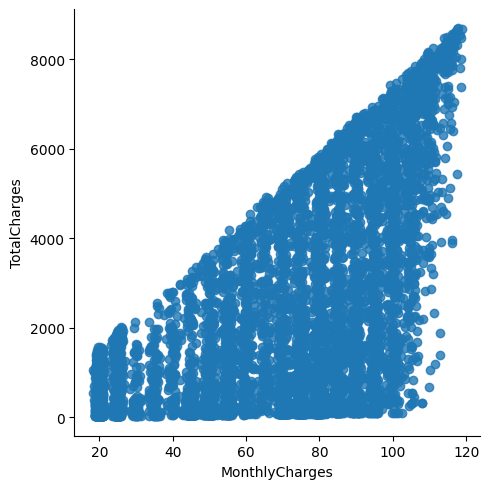

In [ ]:
sns.lmplot(data=new_df_dummies,x='MonthlyCharges',y='TotalCharges',fit_reg=False)

In [ ]:
new_df_dummies['MonthlyCharges'].corr(new_df_dummies['TotalCharges'])

np.float64(0.6510648032262027)

Churn by Monthly Charges and Total Charges

/tmp/ipykernel_953/1171139749.py:1: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  Mth=sns.kdeplot(new_df_dummies.MonthlyCharges[(new_df_dummies["Churn"]==0)],color="Red",shade=True)
/tmp/ipykernel_953/1171139749.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  Mth=sns.kdeplot(new_df_dummies.MonthlyCharges[(new_df_dummies["Churn"]==1)],ax=Mth,color="Blue",shade=True)


Text(0.5, 1.0, 'Monthly charges by churn')

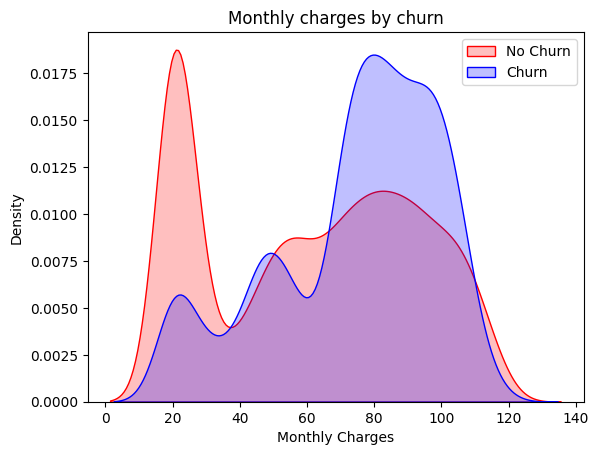

In [ ]:
Mth=sns.kdeplot(new_df_dummies.MonthlyCharges[(new_df_dummies["Churn"]==0)],color="Red",shade=True)
Mth=sns.kdeplot(new_df_dummies.MonthlyCharges[(new_df_dummies["Churn"]==1)],ax=Mth,color="Blue",shade=True)
Mth.legend(["No Churn","Churn"],loc='upper right')
Mth.set_ylabel('Density')
Mth.set_xlabel('Monthly Charges')
Mth.set_title('Monthly charges by churn')

/tmp/ipykernel_953/3747290135.py:1: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  Mth=sns.kdeplot(new_df_dummies.TotalCharges[(new_df_dummies["Churn"]==0)],color="Red",shade=True)
/tmp/ipykernel_953/3747290135.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  Mth=sns.kdeplot(new_df_dummies.TotalCharges[(new_df_dummies["Churn"]==1)],ax=Mth,color="Blue",shade=True)


Text(0.5, 1.0, 'Monthly charges by churn')

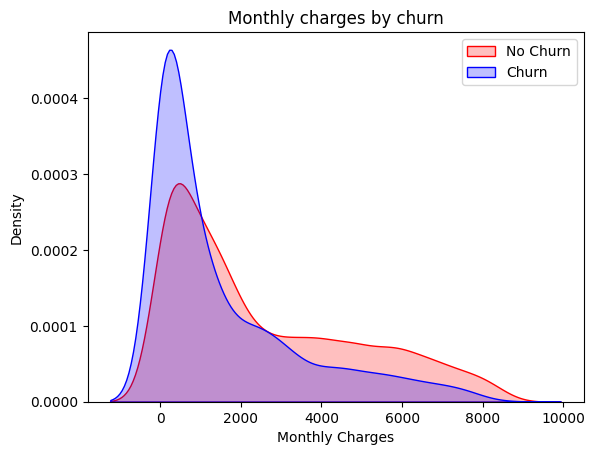

In [ ]:
Mth=sns.kdeplot(new_df_dummies.TotalCharges[(new_df_dummies["Churn"]==0)],color="Red",shade=True)
Mth=sns.kdeplot(new_df_dummies.TotalCharges[(new_df_dummies["Churn"]==1)],ax=Mth,color="Blue",shade=True)
Mth.legend(["No Churn","Churn"],loc='upper right')
Mth.set_ylabel('Density')
Mth.set_xlabel('Monthly Charges')
Mth.set_title('Monthly charges by churn')

**Bulid a corelation of all predictors with 'Churn'**

<Axes: >

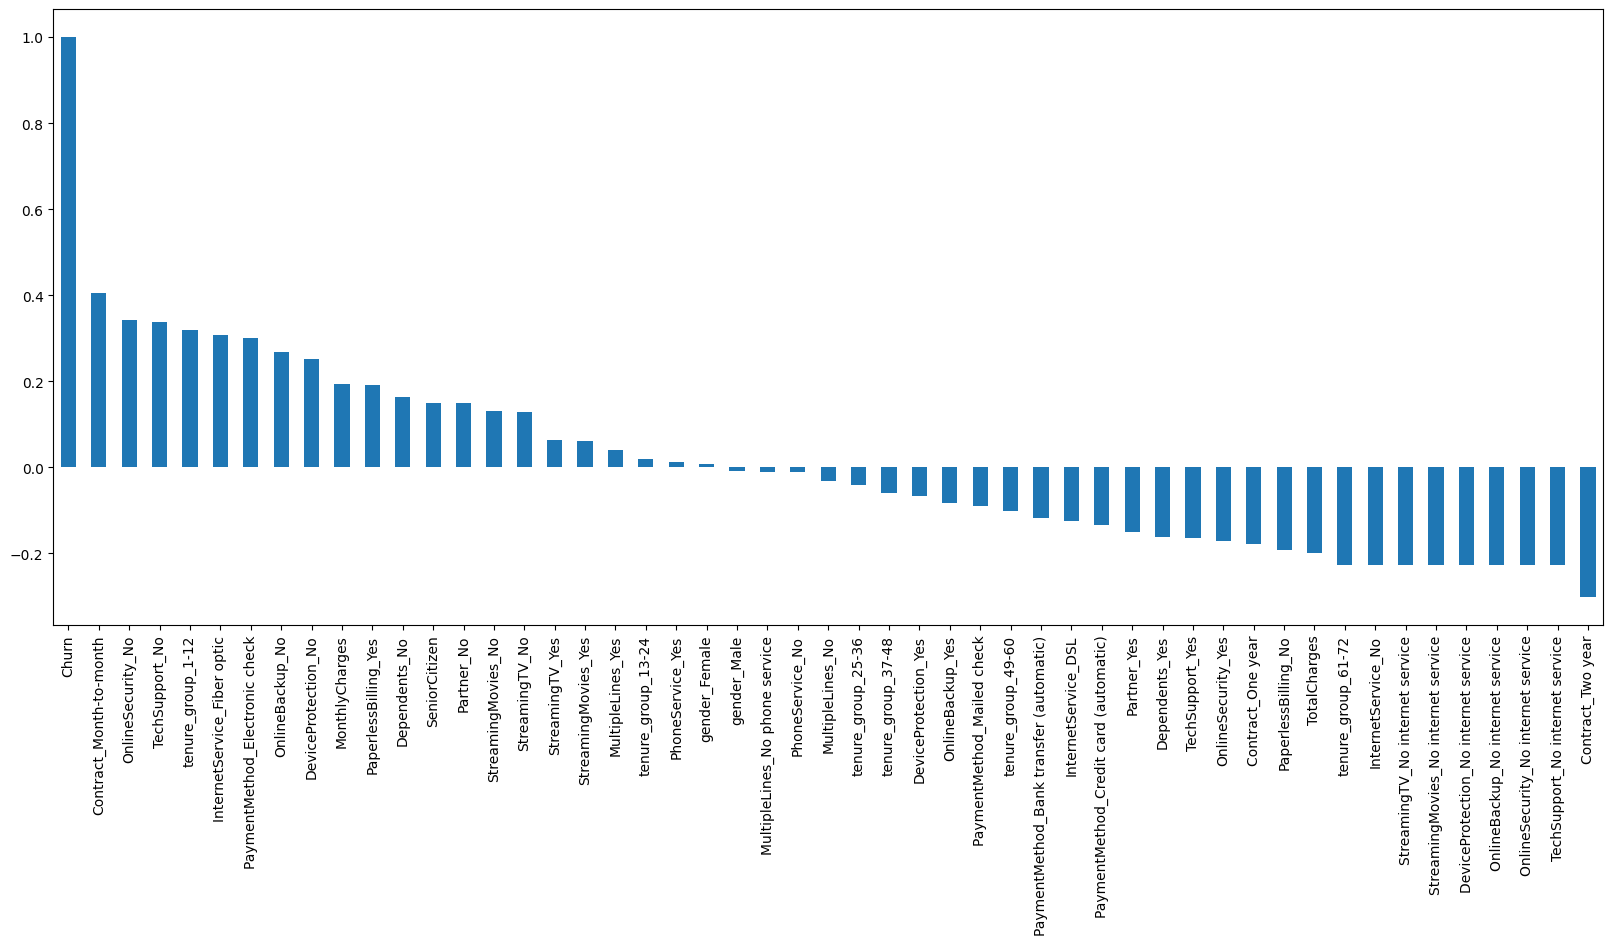

In [ ]:
plt.figure(figsize=(20,8))
new_df_dummies.corr()['Churn'].sort_values(ascending=False).plot(kind='bar')

<Axes: >

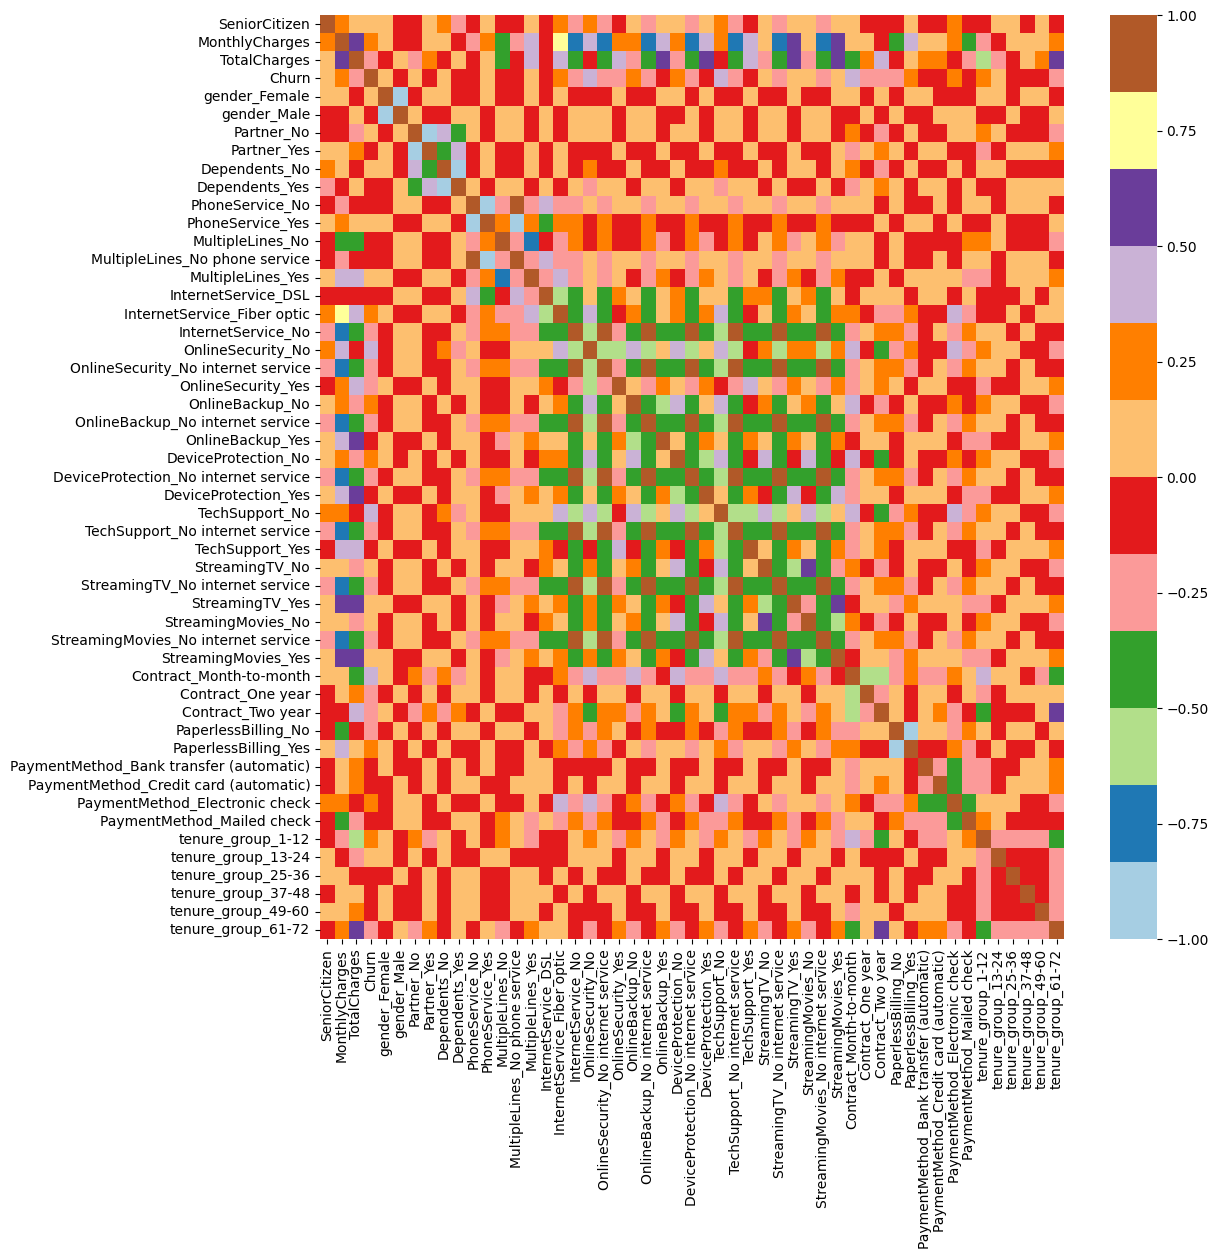

In [ ]:
plt.figure(figsize=(12,12))
sns.heatmap(new_df_dummies.corr(),cmap="Paired")

**CONCLUSION**

1. Electronic check medium are highest churners

2. Contract Type-Monthly customers are likely to churn because of no contract terms, as they are free to go customers

3. No Online security, No Tech Support category are high churners

4. Non senior citizens are high churners